##libraries and source data

In [ ]:
import requests
import os
from pyspark.sql import SparkSession
from pyspark.sql.functions import col, hour, dayofmonth, concat_ws, lit, count
from pyspark.sql.functions import year, unix_timestamp, sum, month, lpad

In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
directory = '/content/drive/MyDrive/MITBDS/parquet_files_2024_2025'

In [ ]:
pip install pyspark

In [ ]:
spark = SparkSession.builder.appName("MapReduceTripData").getOrCreate()

In [ ]:
parquet_files_in_dir = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.parquet')]

if parquet_files_in_dir:
    sample_parquet_file = parquet_files_in_dir[0]
    print(f"Reading data from: {sample_parquet_file}")

    sample_df = spark.read.parquet(sample_parquet_file)

    print("\nContent of the first parquet file (top 10 rows):")
    sample_df.show(10)
else:
    print(f"No parquet files found in the directory: {directory}")

Reading data from: /content/drive/MyDrive/MITBDS/parquet_files_2024_2025/yellow_tripdata_2025-10.parquet

Content of the first parquet file (top 10 rows):
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+------------------+-------------------+-------------------+---------------------+------------------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|cbd_congestion_fee|         started_at|           ended_at|trip_duration_seconds|     avg_speed_mph|
+--------+--------------------+---------------------+---------------+-------------+----------+---------

## transformation

In [ ]:
parquet_files = [os.path.join(directory, f) for f in os.listdir(directory) if f.endswith('.parquet')]

spark_df = spark.read.parquet(*parquet_files)

transformed_df = (spark_df.filter((year(col("tpep_pickup_datetime")) == 2025) | (year(col("tpep_pickup_datetime")) == 2024))
                  .withColumn("trip_hour", hour(col("tpep_pickup_datetime")))
                  .withColumn("trip_day", dayofmonth(col("tpep_pickup_datetime")))
                  .withColumn("start_zone", col("PULocationID"))
                  .withColumn("end_zone", col("DOLocationID"))
                  .withColumn("route", concat_ws("-", col("PULocationID"), col("DOLocationID")))
                  .withColumn("trip_duration_seconds", unix_timestamp(col("tpep_dropoff_datetime")) - unix_timestamp(col("tpep_pickup_datetime")))
                  .withColumn("period", concat_ws("", year(col("tpep_pickup_datetime")), lpad(month(col("tpep_pickup_datetime")), 2, "0"))))


transformed_df.select("tpep_pickup_datetime", "start_zone", "end_zone", "trip_hour", "trip_day", "route", "trip_duration_seconds", "trip_distance", "period").show(5)

+--------------------+----------+--------+---------+--------+-------+---------------------+-------------+------+
|tpep_pickup_datetime|start_zone|end_zone|trip_hour|trip_day|  route|trip_duration_seconds|trip_distance|period|
+--------------------+----------+--------+---------+--------+-------+---------------------+-------------+------+
| 2025-05-01 00:07:06|       140|     202|        0|       1|140-202|                 1029|          3.7|202505|
| 2025-05-01 00:07:44|       234|     161|        0|       1|234-161|                  403|         1.03|202505|
| 2025-05-01 00:15:56|       161|     234|        0|       1|161-234|                  477|         1.57|202505|
| 2025-05-01 00:00:09|       138|      90|        0|       1| 138-90|                 1520|         9.48|202505|
| 2025-05-01 00:45:07|        90|     231|        0|       1| 90-231|                  458|          1.8|202505|
+--------------------+----------+--------+---------+--------+-------+---------------------+-----

## grouping

In [ ]:
grouped_df = transformed_df.groupBy("route", "start_zone", "trip_hour", "trip_day", "period").agg(
    sum("trip_distance").alias("total_trip_distance"),
    sum("trip_duration_seconds").alias("total_trip_duration_seconds"),
    count("*").alias("trip_count")
)

grouped_df.show(5)

+-------+----------+---------+--------+------+-------------------+---------------------------+----------+
|  route|start_zone|trip_hour|trip_day|period|total_trip_distance|total_trip_duration_seconds|trip_count|
+-------+----------+---------+--------+------+-------------------+---------------------------+----------+
|246-161|       246|        0|       1|202505|                2.5|                        651|         1|
|  87-85|        87|        0|       1|202505|              12.74|                       3278|         2|
|230-164|       230|        0|       1|202505|               5.63|                       2058|         5|
|164-114|       164|        0|       1|202505|               4.95|                       1499|         3|
| 246-87|       246|        0|       1|202505|               4.91|                        846|         1|
+-------+----------+---------+--------+------+-------------------+---------------------------+----------+
only showing top 5 rows


## output

In [ ]:
output_directory_transformed = f"{directory}/transformed_df_output_v2"
output_directory_grouped = f"{directory}/grouped_df_output_v2"

grouped_df = grouped_df.withColumn("avg_speed_mph", col("total_trip_distance") / col("total_trip_duration_seconds") * 3600)

transformed_df.write.mode("overwrite").parquet(output_directory_transformed)
grouped_df.write.mode("overwrite").parquet(output_directory_grouped)

print(f"Transformed DataFrame saved to: {output_directory_transformed}")
print(f"Grouped DataFrame saved to: {output_directory_grouped}")

Transformed DataFrame saved to: /content/drive/MyDrive/MITBDS/parquet_files_2024_2025/transformed_df_output_v2
Grouped DataFrame saved to: /content/drive/MyDrive/MITBDS/parquet_files_2024_2025/grouped_df_output_v2


# transformed and grouped datasets

In [ ]:
input_directory_transformed = f"{directory}/transformed_df_output_v2"
input_directory_grouped = f"{directory}/grouped_df_output_v2"

read_transformed_df = spark.read.parquet(input_directory_transformed)
read_grouped_df = spark.read.parquet(input_directory_grouped)

print("Transformed")
read_transformed_df.show(5)

print("\nGrouped DataFrame")
read_grouped_df.show(5)

Transformed
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+-------+----------+------------+---------------------+------------+--------------------+-----------+-------------------+-------------------+---------------------+------------------+---------+--------+----------+--------+-------+------+
|VendorID|tpep_pickup_datetime|tpep_dropoff_datetime|passenger_count|trip_distance|RatecodeID|store_and_fwd_flag|PULocationID|DOLocationID|payment_type|fare_amount|extra|mta_tax|tip_amount|tolls_amount|improvement_surcharge|total_amount|congestion_surcharge|airport_fee|         started_at|           ended_at|trip_duration_seconds|     avg_speed_mph|trip_hour|trip_day|start_zone|end_zone|  route|period|
+--------+--------------------+---------------------+---------------+-------------+----------+------------------+------------+------------+------------+-----------+-----+------

# DAG visualization

In [ ]:
print("\nSpark DAG Visualization for grouped_df (Logical and Physical Plan):")
grouped_df.explain(True)


Spark DAG Visualization for grouped_df (Logical and Physical Plan):
== Parsed Logical Plan ==
'Project [unresolvedstarwithcolumns(avg_speed_mph, '`*`('`/`('total_trip_distance, 'total_trip_duration_seconds), 3600), None)]
+- Project [route#813, start_zone#811L, trip_hour#809, trip_day#810, period#815, total_trip_distance#844, total_trip_duration_seconds#845L, trip_count#846L, ((total_trip_distance#844 / cast(total_trip_duration_seconds#845L as double)) * cast(3600 as double)) AS avg_speed_mph#914]
   +- Aggregate [route#813, start_zone#811L, trip_hour#809, trip_day#810, period#815], [route#813, start_zone#811L, trip_hour#809, trip_day#810, period#815, sum(trip_distance#789) AS total_trip_distance#844, sum(trip_duration_seconds#814L) AS total_trip_duration_seconds#845L, count(1) AS trip_count#846L]
      +- Project [VendorID#785L, tpep_pickup_datetime#786, tpep_dropoff_datetime#787, passenger_count#788L, trip_distance#789, RatecodeID#790L, store_and_fwd_flag#791, PULocationID#792L, DOL

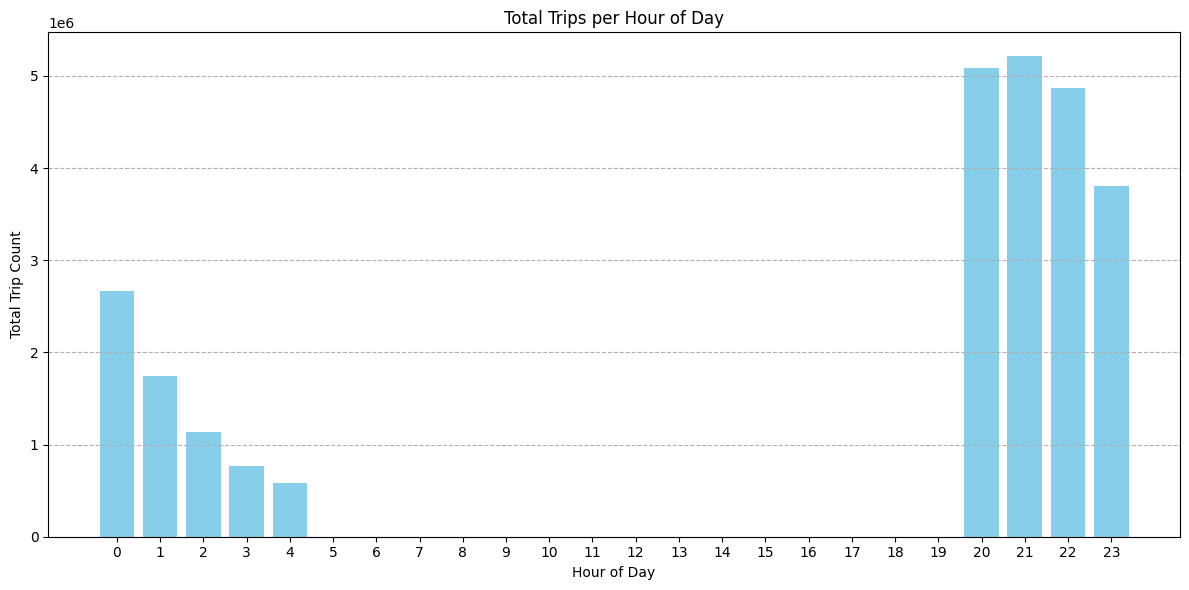

In [ ]:
import matplotlib.pyplot as plt
trips_per_hour = grouped_df.groupBy("trip_hour").agg(sum("trip_count").alias("total_trips"))

trips_per_hour = trips_per_hour.orderBy("trip_hour")
trips_per_hour_pd = trips_per_hour.toPandas()

plt.figure(figsize=(12, 6))
plt.bar(trips_per_hour_pd['trip_hour'], trips_per_hour_pd['total_trips'], color='skyblue')
plt.xlabel('Hour of Day')
plt.ylabel('Total Trip Count')
plt.title('Total Trips per Hour of Day')
plt.xticks(range(24))
plt.grid(axis='y', linestyle='--')
plt.tight_layout()
plt.show()